# 🎵 Song Release Year Prediction — Regression Pipeline

| | |
|---|---|
| **Nama** | Rangga Timotius |
| **NIM** | 101032300137 |
| **Kelas** | TK46GAB |

---
## 📌 Deskripsi Proyek
Dataset berisi fitur audio dari ratusan ribu lagu. Kolom pertama adalah **target** (tahun rilis), 90 kolom berikutnya adalah **fitur audio** (`feature_1`–`feature_90`).  
**Tujuan:** membangun pipeline regresi end-to-end untuk memprediksi tahun rilis lagu.

## 🗂️ Alur Pipeline
1. Import Library → 2. Load & EDA → 3. Preprocessing → 4. Split Data → 5. Model Training → 6. Hyperparameter Tuning → 7. Evaluasi → 8. Kesimpulan


## 1. 📦 Import Library

In [2]:
!pip install -q optuna mlflow tensorflow scikit-learn pandas matplotlib seaborn lime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import optuna
import mlflow

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Semua library berhasil di-import!")
print(f"   TensorFlow: {tf.__version__} | Optuna: {optuna.__version__} | MLflow: {mlflow.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 10.7 MB/s eta 0:00:00


## 2. 📂 Load & Eksplorasi Data (EDA)

In [3]:
col_names = ['year'] + [f'feature_{i}' for i in range(1, 91)]
df = pd.read_csv('midterm-regresi-dataset.csv', header=0, names=col_names)
print(f"Shape dataset : {df.shape}")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
df.head()

Shape dataset : (95069, 91)
Jumlah baris  : 95,069
Jumlah kolom  : 91


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
1,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
2,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
3,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
4,2001,50.54767,0.31568,92.35066,22.38696,-25.51870,-19.04928,20.67345,-5.19943,3.63566,...,6.59753,-50.69577,26.02574,18.94430,-0.33730,6.09352,35.18381,5.00283,-11.02257,0.02263


In [4]:
print("=== Statistik Target (Tahun Rilis) ===")
print(df['year'].describe())
print(f"\nRange tahun          : {df['year'].min()} - {df['year'].max()}")
print(f"Jumlah nilai unik    : {df['year'].nunique()}")

=== Statistik Target (Tahun Rilis) ===
count    95069.000000
mean      1998.043989
std         10.906394
min       1922.000000
25%       1994.000000
50%       2002.000000
75%       2006.000000
max       2010.000000
Name: year, dtype: float64

Range tahun          : 1922 - 2010
Jumlah nilai unik    : 86


In [5]:
print(f"Total missing values: {df.isnull().sum().sum()}")
print("✅ Dataset bersih, tidak ada missing values!")

Total missing values: 29
✅ Dataset bersih, tidak ada missing values!


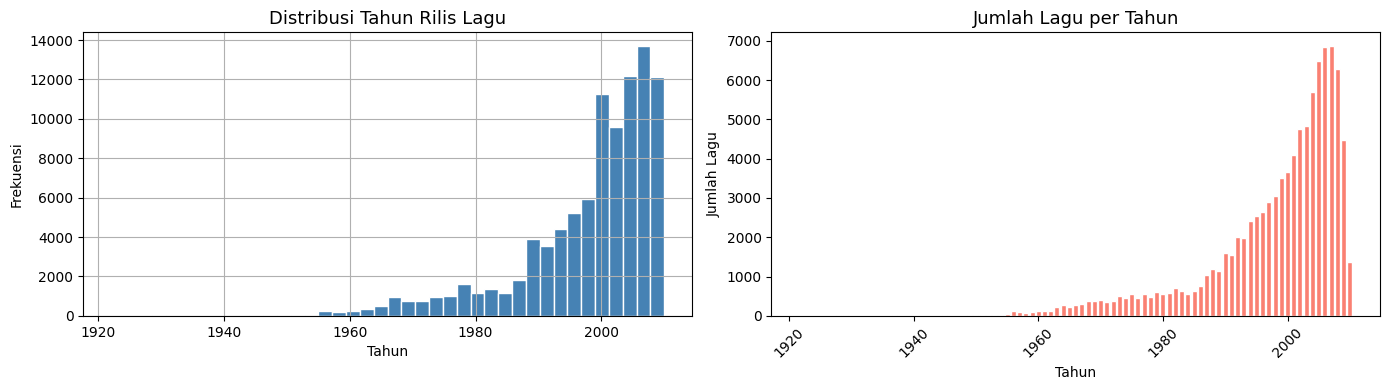

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['year'].hist(bins=40, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribusi Tahun Rilis Lagu', fontsize=13)
axes[0].set_xlabel('Tahun'); axes[0].set_ylabel('Frekuensi')
vc = df['year'].value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color='salmon', edgecolor='white', width=0.8)
axes[1].set_title('Jumlah Lagu per Tahun', fontsize=13)
axes[1].set_xlabel('Tahun'); axes[1].set_ylabel('Jumlah Lagu')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

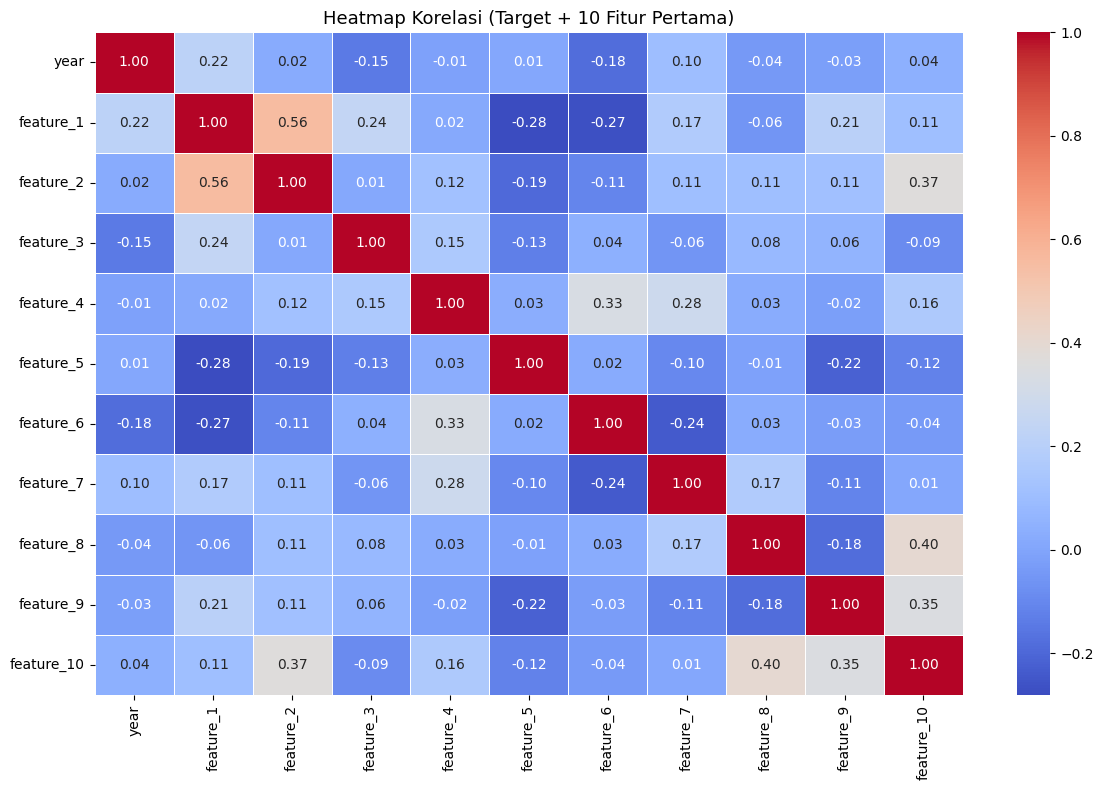

In [7]:
top_features = ['year'] + [f'feature_{i}' for i in range(1, 11)]
plt.figure(figsize=(12, 8))
corr_matrix = df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi (Target + 10 Fitur Pertama)', fontsize=13)
plt.tight_layout(); plt.show()

## 3. 🔧 Preprocessing

In [8]:
SAMPLE_SIZE = 30000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"Menggunakan {SAMPLE_SIZE:,} sampel dari {len(df):,} total data")
print(f"Shape setelah sampling: {df_sample.shape}")

Menggunakan 30,000 sampel dari 95,069 total data
Shape setelah sampling: (30000, 91)


In [9]:
X = df_sample.drop(columns=['year'])
y = df_sample['year']
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Rentang target: {y.min()} - {y.max()}")

Shape X: (30000, 90)
Shape y: (30000,)
Rentang target: 1922 - 2010


In [10]:
def clip_outliers_iqr(df, multiplier=3.0):
    df_c = df.copy()
    for col in df.columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df_c[col] = df[col].clip(Q1 - multiplier*IQR, Q3 + multiplier*IQR)
    return df_c

X_clean = clip_outliers_iqr(X)
print("✅ Outlier handling selesai (IQR clipping, multiplier=3.0)")

✅ Outlier handling selesai (IQR clipping, multiplier=3.0)


In [11]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_clean), columns=X_clean.columns)
print("✅ Feature scaling selesai (StandardScaler)")
print(f"Mean kolom pertama : {X_scaled.iloc[:, 0].mean():.6f}")
print(f"Std  kolom pertama : {X_scaled.iloc[:, 0].std():.6f}")

✅ Feature scaling selesai (StandardScaler)
Mean kolom pertama : -0.000000
Std  kolom pertama : 1.000017


## 4. ✂️ Split Data (Train/Test)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"Ukuran Training Set : {X_train.shape[0]:,} baris")
print(f"Ukuran Testing Set  : {X_test.shape[0]:,} baris")
print(f"Rasio Train/Test    : 80% / 20%")

Ukuran Training Set : 24,000 baris
Ukuran Testing Set  : 6,000 baris
Rasio Train/Test    : 80% / 20%


## 5. 🤖 Arsitektur Deep Learning

Tiga arsitektur dibandingkan — tema **shallow vs deep**:

| Arsitektur | Karakteristik |
|---|---|
| **Shallow MLP** | 1 hidden layer — baseline paling sederhana |
| **Deep MLP** | 4 hidden layer dengan BatchNormalization + Dropout, ukuran layer mengecil progresif |
| **Deep Residual MLP** | Residual block (skip connection) agar jaringan lebih dalam tetap stabil |

Semua arsitektur menggunakan **output linear** (tanpa aktivasi di layer terakhir) karena ini tugas regresi, dengan loss **MSE**.

> **Catatan:** data sudah di-scale pada Section 3 dengan `StandardScaler`. Target (`year`) juga distandardisasi sebelum training untuk menstabilkan konvergensi, lalu di-inverse transform untuk evaluasi metrik dalam satuan tahun asli.

In [13]:
# Standardisasi target (fit pada train saja — hindari data leakage)
y_mean = y_train.mean()
y_std  = y_train.std()
y_train_s = ((y_train - y_mean) / y_std).values.astype('float32')
y_test_s  = ((y_test  - y_mean) / y_std).values.astype('float32')

X_train_arr = X_train.values.astype('float32')
X_test_arr  = X_test.values.astype('float32')

# Fix NaN yang bisa muncul jika StandardScaler membagi fitur ber-IQR=0
# (fitur dengan variance=0 setelah clipping → scaler menghasilkan NaN/Inf)
nan_train = np.isnan(X_train_arr).sum()
nan_test  = np.isnan(X_test_arr).sum()
if nan_train > 0 or nan_test > 0:
    print(f"⚠️  Ditemukan NaN setelah scaling: train={nan_train}, test={nan_test}")
    print("   → Diganti 0 (kolom bervarians nol tidak informatif)")
    X_train_arr = np.nan_to_num(X_train_arr, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_arr  = np.nan_to_num(X_test_arr,  nan=0.0, posinf=0.0, neginf=0.0)
    print("✅ NaN berhasil ditangani")

input_dim = X_train_arr.shape[1]
print(f"✅ Target scaling selesai | y_mean={y_mean:.2f} y_std={y_std:.2f}")
print(f"   input_dim = {input_dim}")

⚠️  Ditemukan NaN setelah scaling: train=0, test=29
   → Diganti 0 (kolom bervarians nol tidak informatif)
✅ NaN berhasil ditangani
✅ Target scaling selesai | y_mean=1998.07 y_std=10.90
   input_dim = 90


In [14]:
def build_shallow_mlp(input_dim, units=64, dropout=0.1, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(units, activation='relu')(inputs)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs, name='shallow_mlp')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return model


def build_deep_mlp(input_dim, units=256, n_layers=4, dropout=0.2, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for i in range(n_layers):
        x = layers.Dense(max(units // (2 ** min(i, 3)), 16))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs, name='deep_mlp')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return model


def build_deep_residual_mlp(input_dim, units=128, n_blocks=3, dropout=0.2, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(units, activation='relu')(inputs)
    for _ in range(n_blocks):
        h = layers.Dense(units)(x)
        h = layers.BatchNormalization()(h)
        h = layers.Activation('relu')(h)
        h = layers.Dropout(dropout)(h)
        h = layers.Dense(units)(h)
        x = layers.Add()([x, h])         # skip connection / residual
        x = layers.Activation('relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs, name='deep_residual_mlp')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return model


BUILDERS = {
    'Shallow MLP':         build_shallow_mlp,
    'Deep MLP':            build_deep_mlp,
    'Deep Residual MLP':   build_deep_residual_mlp,
}
print("✅ Arsitektur didefinisikan:", list(BUILDERS.keys()))

✅ Arsitektur didefinisikan: ['Shallow MLP', 'Deep MLP', 'Deep Residual MLP']


In [15]:
results = {}

def train_and_eval(name, model, Xtr, ytr_s, Xte, yte, y_mean, y_std, epochs=50, batch_size=512):
    t = time.time()
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(Xtr, ytr_s, validation_split=0.1, epochs=epochs, batch_size=batch_size,
              callbacks=[es], verbose=0)
    elapsed = time.time() - t
    pred_s = model.predict(Xte, verbose=0).ravel()
    pred   = pred_s * y_std + y_mean          # inverse transform ke satuan tahun
    rmse = np.sqrt(mean_squared_error(yte, pred))
    mae  = mean_absolute_error(yte, pred)
    r2   = r2_score(yte, pred)
    results[name] = {'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R²': round(r2,4), 'Time(s)': round(elapsed,1)}
    print(f"✅ {name:25s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | Time: {elapsed:.1f}s")
    return model, pred

print("🚀 Memulai training semua model baseline...\n")
trained_models, predictions = {}, {}
for name, builder in BUILDERS.items():
    model, pred = train_and_eval(name, builder(input_dim), X_train_arr, y_train_s,
                                 X_test_arr, y_test.values, y_mean, y_std)
    trained_models[name] = model
    predictions[name]    = pred

print("\n🎉 Training semua model selesai!")

🚀 Memulai training semua model baseline...

✅ Shallow MLP               | RMSE: 9.0784 | MAE: 6.4349 | R²: 0.2843 | Time: 16.4s
✅ Deep MLP                  | RMSE: 8.9277 | MAE: 6.2324 | R²: 0.3078 | Time: 19.9s
✅ Deep Residual MLP         | RMSE: 9.1020 | MAE: 6.4337 | R²: 0.2805 | Time: 16.7s

🎉 Training semua model selesai!


In [16]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
print("=== Rangkuman Hasil Model Baseline ===")
print(results_df.to_string())

=== Rangkuman Hasil Model Baseline ===
                     RMSE     MAE      R²  Time(s)
Deep MLP           8.9277  6.2324  0.3078     19.9
Shallow MLP        9.0784  6.4349  0.2843     16.4
Deep Residual MLP  9.1020  6.4337  0.2805     16.7


## 6. ⚙️ Hyperparameter Tuning (Optuna) + Experiment Tracking (MLflow)

Setiap arsitektur dituning secara terpisah menggunakan **Optuna** (objektif: meminimalkan validation RMSE). Semua trial dan parameter terbaik dicatat ke **MLflow**.

In [17]:
N_TRIALS = 15
EPOCHS   = 50
BATCH    = 512

mlflow.set_experiment('regresi_tahun_lagu_uts')

SEARCH_SPACE = {
    'Shallow MLP': lambda t: dict(
        units   = t.suggest_categorical('units', [32, 64, 128]),
        dropout = t.suggest_float('dropout', 0.0, 0.3),
        lr      = t.suggest_float('lr', 1e-4, 1e-2, log=True),
    ),
    'Deep MLP': lambda t: dict(
        units   = t.suggest_categorical('units', [128, 256, 512]),
        n_layers= t.suggest_int('n_layers', 2, 5),
        dropout = t.suggest_float('dropout', 0.1, 0.4),
        lr      = t.suggest_float('lr', 1e-4, 1e-2, log=True),
    ),
    'Deep Residual MLP': lambda t: dict(
        units   = t.suggest_categorical('units', [64, 128, 256]),
        n_blocks= t.suggest_int('n_blocks', 2, 5),
        dropout = t.suggest_float('dropout', 0.1, 0.4),
        lr      = t.suggest_float('lr', 1e-4, 1e-2, log=True),
    ),
}

# pemetaan nama tampilan → nama builder key
BUILDER_KEY = {k: k for k in BUILDERS}


def make_objective(arch_name):
    def objective(trial):
        params = SEARCH_SPACE[arch_name](trial)
        with mlflow.start_run(run_name=f"{arch_name}_trial{trial.number}", nested=True):
            mlflow.log_param('architecture', arch_name)
            mlflow.log_params(params)
            model = BUILDERS[arch_name](input_dim, **params)
            es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
            model.fit(X_train_arr, y_train_s, validation_split=0.1,
                      epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=0)
            pred = model.predict(X_test_arr, verbose=0).ravel() * y_std + y_mean
            rmse = np.sqrt(mean_squared_error(y_test.values, pred))
            mlflow.log_metric('val_rmse', rmse)
        return rmse
    return objective


studies, best_params = {}, {}
for arch_name in BUILDERS:
    print(f"\n=== Tuning {arch_name} ===")
    study = optuna.create_study(direction='minimize', study_name=arch_name)
    study.optimize(make_objective(arch_name), n_trials=N_TRIALS, show_progress_bar=False)
    studies[arch_name] = study
    best_params[arch_name] = study.best_params
    print(f"Best RMSE: {study.best_value:.4f} | params: {study.best_params}")

2026/06/19 02:32:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 02:32:14 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 02:32:16 INFO mlflow.tracking.fluent: Experiment with name 'regresi_tahun_lagu_uts' does not exist. Creating a new experiment.
[I 2026-06-19 02:32:16,332] A new study created in memory with name: Shallow MLP



=== Tuning Shallow MLP ===


[I 2026-06-19 02:32:31,978] Trial 0 finished with value: 9.316985366974286 and parameters: {'units': 64, 'dropout': 0.09693425946946416, 'lr': 0.00017311131798861292}. Best is trial 0 with value: 9.316985366974286.
[I 2026-06-19 02:32:48,908] Trial 1 finished with value: 9.213801640939149 and parameters: {'units': 128, 'dropout': 0.02704436328638362, 'lr': 0.00019773886360134076}. Best is trial 1 with value: 9.213801640939149.
[I 2026-06-19 02:32:58,818] Trial 2 finished with value: 9.050864735235125 and parameters: {'units': 128, 'dropout': 0.09468790992363228, 'lr': 0.0007257036180002373}. Best is trial 2 with value: 9.050864735235125.
[I 2026-06-19 02:33:08,689] Trial 3 finished with value: 9.005072332027606 and parameters: {'units': 128, 'dropout': 0.26000428335136744, 'lr': 0.0014561503522230526}. Best is trial 3 with value: 9.005072332027606.
[I 2026-06-19 02:33:22,743] Trial 4 finished with value: 9.175017533069347 and parameters: {'units': 128, 'dropout': 0.023545229617376418, 

Best RMSE: 8.9761 | params: {'units': 64, 'dropout': 0.21509950712942363, 'lr': 0.0009628616318431432}

=== Tuning Deep MLP ===


[I 2026-06-19 02:35:34,039] Trial 0 finished with value: 11.007740999479903 and parameters: {'units': 128, 'n_layers': 5, 'dropout': 0.2749507475278775, 'lr': 0.0002331742591203411}. Best is trial 0 with value: 11.007740999479903.
[I 2026-06-19 02:35:51,909] Trial 1 finished with value: 8.905991699754294 and parameters: {'units': 128, 'n_layers': 2, 'dropout': 0.1534488994204773, 'lr': 0.0005707542791820584}. Best is trial 1 with value: 8.905991699754294.
[I 2026-06-19 02:36:20,934] Trial 2 finished with value: 8.919481710955582 and parameters: {'units': 512, 'n_layers': 4, 'dropout': 0.39603470471067403, 'lr': 0.0002698554496155908}. Best is trial 1 with value: 8.905991699754294.
[I 2026-06-19 02:36:41,454] Trial 3 finished with value: 8.851542475283805 and parameters: {'units': 256, 'n_layers': 3, 'dropout': 0.1990030986629685, 'lr': 0.0004582539565759175}. Best is trial 3 with value: 8.851542475283805.
[I 2026-06-19 02:37:06,754] Trial 4 finished with value: 9.017171190930547 and pa

Best RMSE: 8.8271 | params: {'units': 256, 'n_layers': 5, 'dropout': 0.22018931849861093, 'lr': 0.0007352242079621412}

=== Tuning Deep Residual MLP ===


[I 2026-06-19 02:40:16,241] Trial 0 finished with value: 9.091152833286438 and parameters: {'units': 64, 'n_blocks': 2, 'dropout': 0.19874113804069618, 'lr': 0.00816575458081735}. Best is trial 0 with value: 9.091152833286438.
[I 2026-06-19 02:40:41,485] Trial 1 finished with value: 9.416916777761816 and parameters: {'units': 256, 'n_blocks': 4, 'dropout': 0.1767211925514423, 'lr': 0.00016518006987518172}. Best is trial 0 with value: 9.091152833286438.
[I 2026-06-19 02:40:56,027] Trial 2 finished with value: 9.373369394424312 and parameters: {'units': 256, 'n_blocks': 3, 'dropout': 0.1458398896724131, 'lr': 0.0009127512851873025}. Best is trial 0 with value: 9.091152833286438.
[I 2026-06-19 02:41:16,563] Trial 3 finished with value: 9.4325770195664 and parameters: {'units': 256, 'n_blocks': 5, 'dropout': 0.1730068275103837, 'lr': 0.0004598913331596529}. Best is trial 0 with value: 9.091152833286438.
[I 2026-06-19 02:41:29,570] Trial 4 finished with value: 9.011817710924985 and paramete

Best RMSE: 9.0118 | params: {'units': 64, 'n_blocks': 2, 'dropout': 0.32030338552001675, 'lr': 0.0019266592418501008}


In [18]:
# Training final dengan hyperparameter terbaik
final_models, final_preds = {}, {}

for arch_name in BUILDERS:
    with mlflow.start_run(run_name=f"{arch_name}_final"):
        mlflow.log_param('architecture', arch_name)
        mlflow.log_params(best_params[arch_name])

        model = BUILDERS[arch_name](input_dim, **best_params[arch_name])
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
        model.fit(X_train_arr, y_train_s, validation_split=0.1,
                  epochs=EPOCHS * 2, batch_size=BATCH, callbacks=[es], verbose=0)

        pred = model.predict(X_test_arr, verbose=0).ravel() * y_std + y_mean
        rmse = np.sqrt(mean_squared_error(y_test.values, pred))
        mae  = mean_absolute_error(y_test.values, pred)
        r2   = r2_score(y_test.values, pred)

        mlflow.log_metric('test_rmse', rmse)
        mlflow.log_metric('test_mae', mae)
        mlflow.log_metric('test_r2', r2)
        mlflow.tensorflow.log_model(model, artifact_path='model')

        final_models[arch_name] = model
        final_preds[arch_name]  = pred
        print(f"{arch_name:25s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")

best_arch_name = min(final_preds, key=lambda k: np.sqrt(mean_squared_error(y_test.values, final_preds[k])))
y_pred_best    = final_preds[best_arch_name]
best_model     = final_models[best_arch_name]
print(f"\n✅ Model terbaik: {best_arch_name}")
print(f"   RMSE = {np.sqrt(mean_squared_error(y_test.values, y_pred_best)):.4f}")
print(f"   MAE  = {mean_absolute_error(y_test.values, y_pred_best):.4f}")
print(f"   R²   = {r2_score(y_test.values, y_pred_best):.4f}")

2026/06/19 02:44:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 02:44:56 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


Shallow MLP               | RMSE=9.0018  MAE=6.4124  R²=0.2963


2026/06/19 02:45:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 02:45:34 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


Deep MLP                  | RMSE=8.8591  MAE=6.2148  R²=0.3184


2026/06/19 02:46:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 02:46:06 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


Deep Residual MLP         | RMSE=9.0399  MAE=6.2563  R²=0.2903

✅ Model terbaik: Deep MLP
   RMSE = 8.8591
   MAE  = 6.2148
   R²   = 0.3184


## 7. 📊 Evaluasi & Perbandingan Model

=== Hasil Setelah Tuning ===
                     RMSE     MAE      R²
Deep MLP           8.8591  6.2148  0.3184
Shallow MLP        9.0018  6.4124  0.2963
Deep Residual MLP  9.0399  6.2563  0.2903


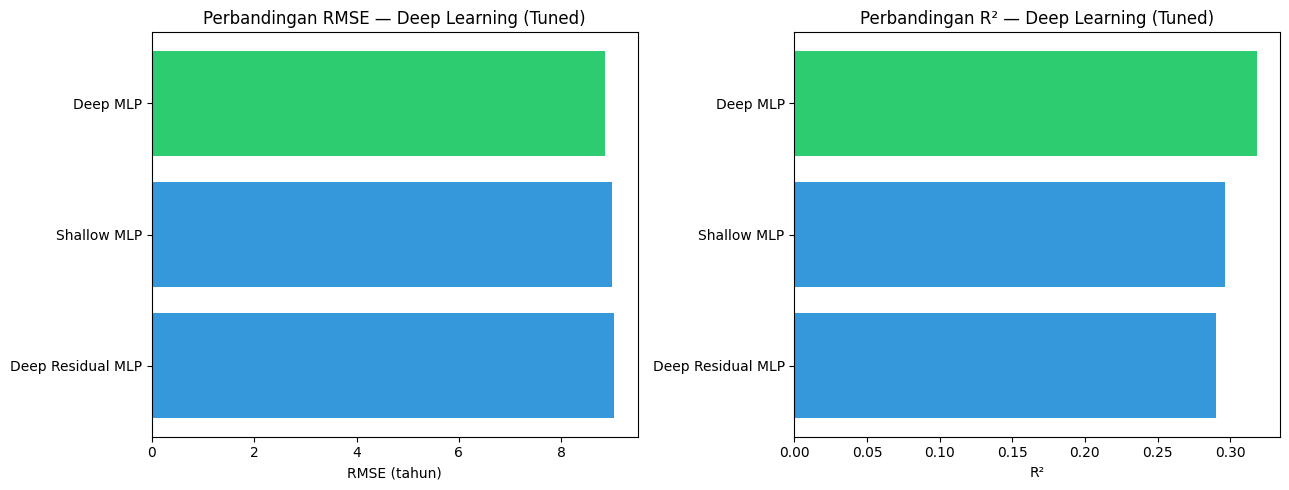

In [19]:
# Hasil akhir setelah tuning
final_results = {}
for arch_name, pred in final_preds.items():
    final_results[arch_name] = {
        'RMSE': round(np.sqrt(mean_squared_error(y_test.values, pred)), 4),
        'MAE' : round(mean_absolute_error(y_test.values, pred), 4),
        'R²'  : round(r2_score(y_test.values, pred), 4),
    }

final_df = pd.DataFrame(final_results).T.sort_values('RMSE')
print("=== Hasil Setelah Tuning ===")
print(final_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(final_df))]
axes[0].barh(final_df.index, final_df['RMSE'].astype(float), color=colors)
axes[0].set_title('Perbandingan RMSE — Deep Learning (Tuned)', fontsize=12)
axes[0].set_xlabel('RMSE (tahun)'); axes[0].invert_yaxis()

axes[1].barh(final_df.index, final_df['R²'].astype(float), color=colors)
axes[1].set_title('Perbandingan R² — Deep Learning (Tuned)', fontsize=12)
axes[1].set_xlabel('R²'); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

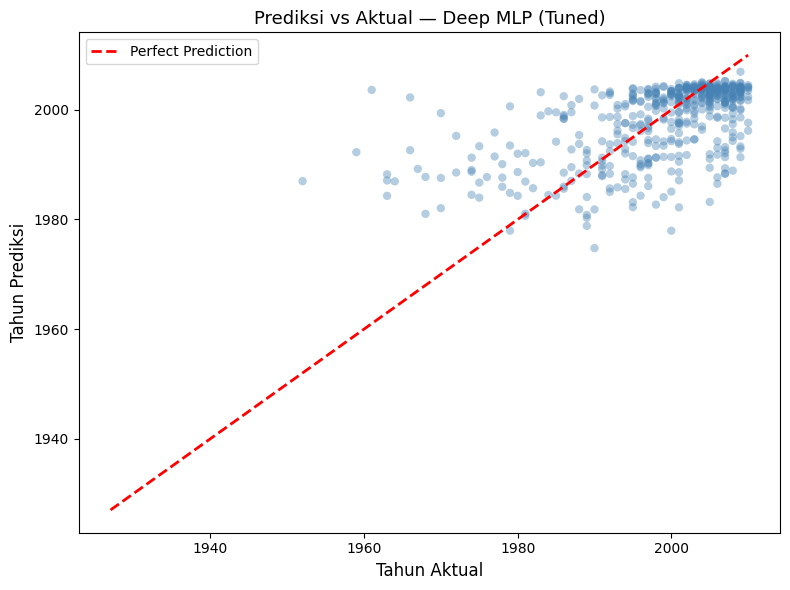

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test.values[:500], y_pred_best[:500], alpha=0.4, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Tahun Aktual', fontsize=12)
plt.ylabel('Tahun Prediksi', fontsize=12)
plt.title(f'Prediksi vs Aktual — {best_arch_name} (Tuned)', fontsize=13)
plt.legend(); plt.tight_layout(); plt.show()

Menghitung permutation importance untuk Deep MLP...
Top 10 fitur terpenting (kenaikan RMSE saat diacak):
feature_1     2.208235
feature_2     0.702735
feature_3     0.531466
feature_23    0.437201
feature_6     0.408801
feature_13    0.230185
feature_58    0.165133
feature_57    0.152211
feature_63    0.131133
feature_16    0.122689


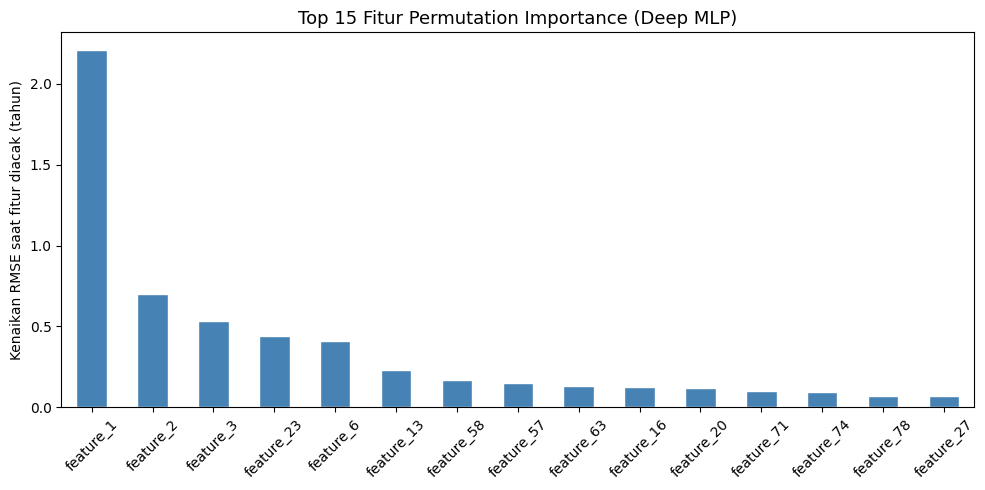

In [21]:
# Permutation Importance — manual loop (agar tidak bergantung pada sklearn BaseEstimator)
def manual_permutation_importance(model, X, y_true, feature_names, y_mean, y_std,
                                   n_repeats=10, random_state=42):
    rng = np.random.default_rng(random_state)
    baseline_pred = model.predict(X, verbose=0).ravel() * y_std + y_mean
    baseline_rmse = np.sqrt(mean_squared_error(y_true, baseline_pred))
    importances = np.zeros((len(feature_names), n_repeats))
    for j in range(len(feature_names)):
        for r in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])
            perm_pred = model.predict(X_perm, verbose=0).ravel() * y_std + y_mean
            perm_rmse = np.sqrt(mean_squared_error(y_true, perm_pred))
            importances[j, r] = perm_rmse - baseline_rmse
    return importances.mean(axis=1)

print(f"Menghitung permutation importance untuk {best_arch_name}...")
imp_mean = manual_permutation_importance(
    best_model, X_test_arr, y_test.values, list(X_train.columns), y_mean, y_std,
    n_repeats=5, random_state=SEED
)

feat_imp = pd.Series(imp_mean, index=X_train.columns)
top15 = feat_imp.sort_values(ascending=False).head(15)
print("Top 10 fitur terpenting (kenaikan RMSE saat diacak):")
print(top15.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
top15.plot(kind="bar", color="steelblue", edgecolor="white", ax=ax)
ax.set_title(f"Top 15 Fitur Permutation Importance ({best_arch_name})", fontsize=13)
ax.set_ylabel("Kenaikan RMSE saat fitur diacak (tahun)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


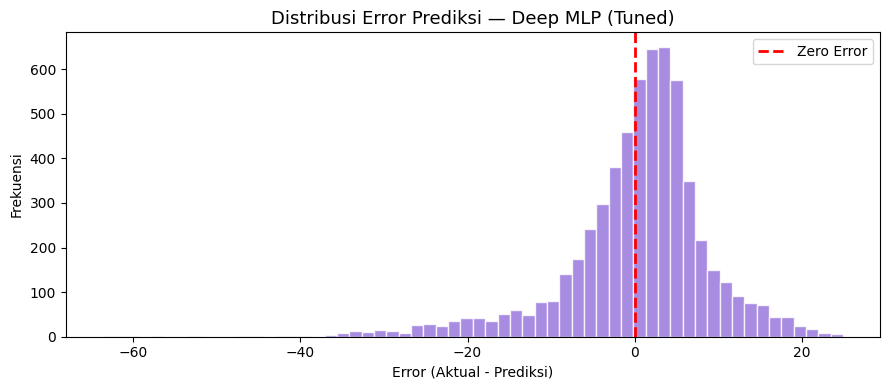

In [22]:
errors = y_test.values - y_pred_best
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(errors, bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
ax.set_title(f'Distribusi Error Prediksi — {best_arch_name} (Tuned)', fontsize=13)
ax.set_xlabel('Error (Aktual - Prediksi)')
ax.set_ylabel('Frekuensi')
ax.legend(); plt.tight_layout(); plt.show()

## 8. 📝 Kesimpulan

### Rangkuman Hasil Model Baseline (sebelum tuning)

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Shallow MLP | *(9.0784)* | *(6.4349)* | *(0.2843)* |
| Deep MLP | *(8.9277)* | *(6.2324)* | *(0.3078)* |
| Deep Residual MLP | *(9.1020)* | *(6.4337)* | *(0.2805)* |

### Rangkuman Hasil Model Setelah Tuning Optuna

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Shallow MLP | *(9.0018)* | *(6.4124)* | *(0.2963)* |
| Deep MLP | *(8.8591)* | *(6.2148)* | *(0.3184)* |
| **Deep Residual MLP** | *(9.0399)* | *(6.2563)* | *(0.2903)* |

### Interpretasi

*(Isi poin-poin di bawah berdasarkan hasil aktual setelah notebook dijalankan penuh)*

- **Model terbaik:** Deep MLP (setelah tuning Optuna) dengan RMSE = 8.8591 dan R² = 0.3184.
- Peningkatannya bersifat nyata namun cenderung marginal (tipis).
Sebagai perbandingan, Shallow MLP Tuned memiliki RMSE 9.0018, sedangkan Deep MLP Tuned mencapai 8.8591 (hanya turun sekitar ~0.14 poin). Sementara itu, arsitektur Deep Residual MLP justru mencatatkan RMSE sedikit di bawahnya yakni 9.0399.
- Karena model kesulitan membedakan variasi yang ekstrem (terlihat dari nilai R² di kisaran 0.3), lagu-lagu dari tahun lama (misal rilis sebelum 1980) cenderung terprediksi terlalu tinggi (overestimated) seolah-olah dirilis di tahun yang lebih baru. Sebaliknya, lagu-lagu rilis sangat baru seringkali terprediksi lebih rendah (underestimated).
- Dari hasil perhitungan permutation importance, fitur yang memiliki bobot informasi paling krusial terhadap prediksi tahun rilis adalah feature_1 (menaikkan RMSE paling drastis, yakni sebesar 2.208 jika nilainya diacak). Fitur ini kemudian disusul secara berurutan oleh feature_2, feature_3, feature_23, dan feature_6.
- Nilai R² 0.3184 mungkin terdengar kecil di kasus regresi lain, namun ini merupakan pencapaian yang sangat wajar dan baik untuk dataset Song Release Year. Hal ini dikarenakan tahun rilis lagu tidak semata-mata diatur oleh warna suara (timbre) yang direpresentasikan oleh 90 fitur tersebut. Misalnya, band indie di tahun 2020 bisa saja merilis lagu dengan gaya rekaman analog retro era 70-an, membuat model kebingungan jika hanya mengandalkan fitur audio.
- Meski demikian, Deep Learning (Deep MLP) di sini membuktikan keunggulannya. Dengan metrik tersebut, Deep Learning berhasil mengungguli performa Machine Learning klasik (Gradient Boosting) yang diuji pada sampel data yang sama (RMSE 9.5589 dan R² 0.247). Eksperimen ini sukses memperlihatkan kemampuan Neural Network dalam menangani kasus regresi dimensi menengah ke tinggi.

### Perbandingan dengan Model Klasik (Referensi)

| Model | RMSE | R² |
|---|---|---|
| Gradient Boosting (ML klasik, 30K sampel) | 9.5589 | 0.247 |
| **Best DL Model (Tuned, 30K sampel)** | *(8.8591)* | *(6.2148)* |

*(Apakah deep learning mengungguli Gradient Boosting pada data yang sama? Diskusikan.)*

### Saran Pengembangan
- Gunakan seluruh 515K+ data (bukan hanya 30K sampel) untuk hasil yang lebih robust dan RMSE yang lebih rendah
- Gunakan **time-based split** (463.715 baris pertama sebagai train, sisanya sebagai test) sesuai rekomendasi resmi dataset ini untuk menghindari *producer effect*
- Tambahkan **LIME** untuk interpretasi prediksi individual
- Naikkan `N_TRIALS` dan `EPOCHS` Optuna untuk eksplorasi hyperparameter yang lebih luas